## Plots from Data

### V1 - Discharge

C:\Users\Jacob\AppData\Local\Temp\ipykernel_14516\2598724873.py:71: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0


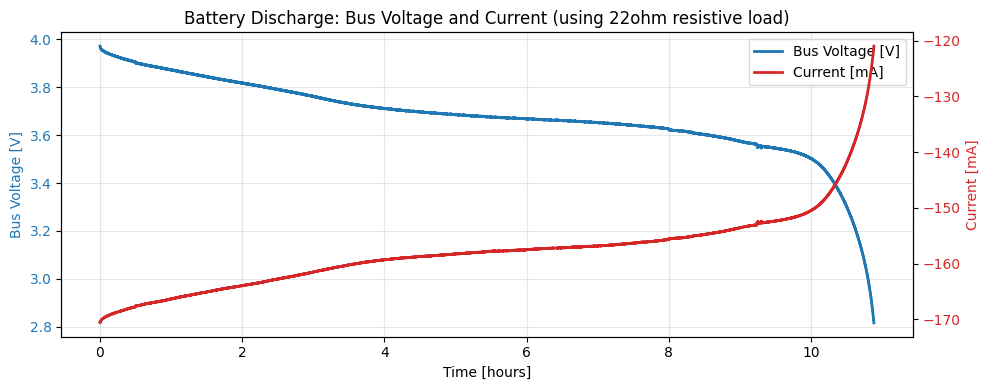

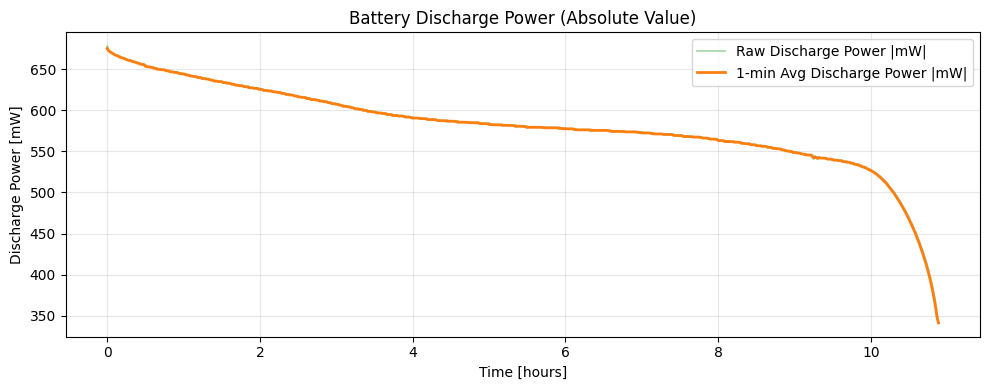

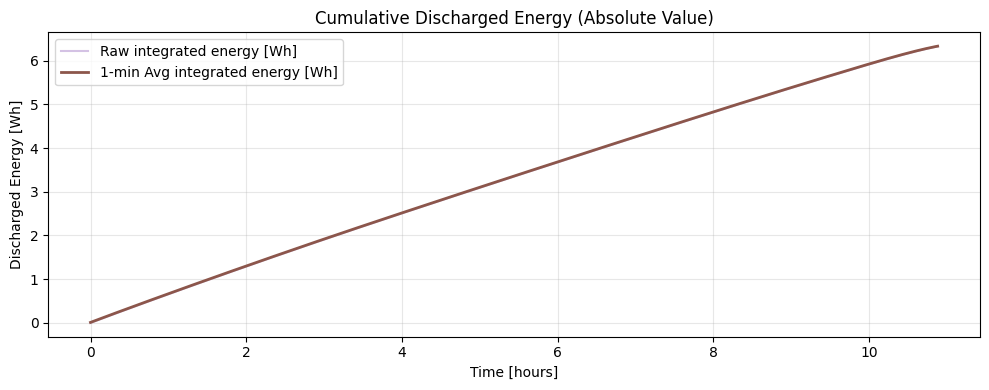

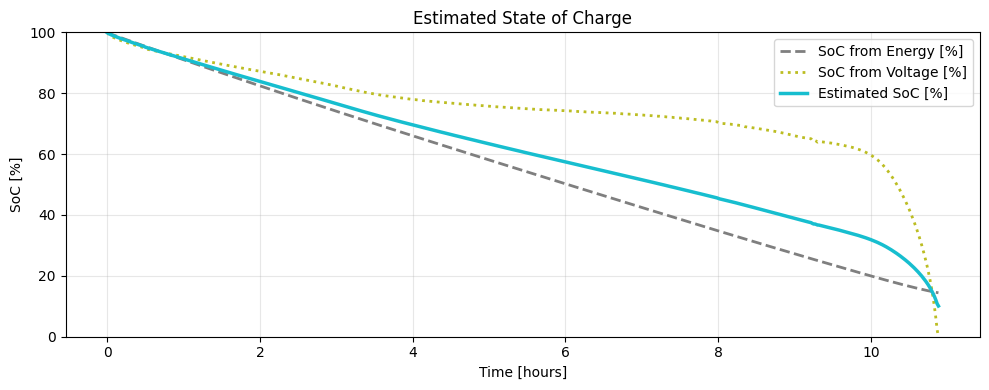

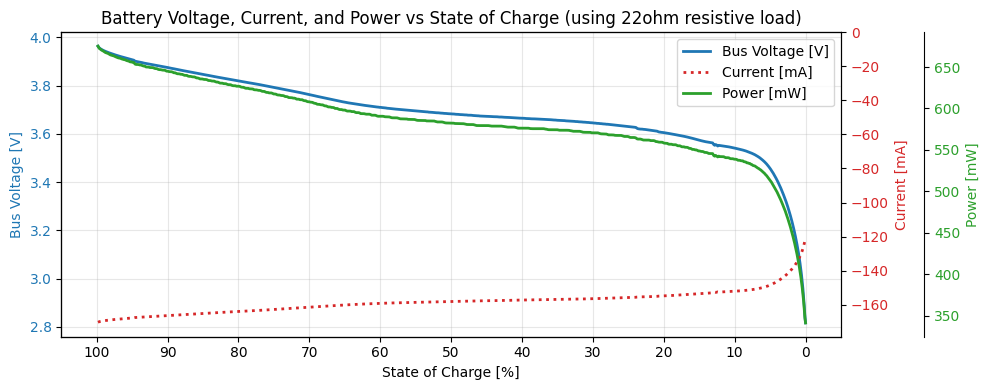

Original rows: 44371
Discharge rows used: 39101
Discharge start: 2026-04-19 10:40:02.801000
Discharge end:   2026-04-19 21:33:02.974000
Duration:        10.883 h
Final integrated energy: 6.3263 Wh
Final 1-min averaged integrated energy: 6.3323 Wh
Final SoC from energy: 14.43 %
Final SoC from voltage: 0.00 %
Final estimated SoC: 10.10 %


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# Settings
# ----------------------------
csv_file = Path("BATTERY_ina226_log_20260419_093223.csv")

# Negative current = discharge
discharge_threshold_mA = -10.0

# Battery nominal energy
battery_capacity_Wh = 7.4

# Weighting for combined SoC estimate
# 0.7 = energy-based, 0.3 = voltage-based
soc_energy_weight = 0.7
soc_voltage_weight = 0.3

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(csv_file)

df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
df = df.dropna(subset=["pc_time"]).copy()
df = df.sort_values("pc_time").reset_index(drop=True)
df = df.drop_duplicates(subset="pc_time", keep="first").copy()

numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()

# ----------------------------
# Find discharge block
# ----------------------------
is_discharge = df["current_mA"] < discharge_threshold_mA

if not is_discharge.any():
    raise ValueError(
        f"No rows found with current_mA < {discharge_threshold_mA}. "
        f"Try threshold -1.0 or -0.1"
    )

start_idx = is_discharge.idxmax()
df_after_start = df.loc[start_idx:].copy()
is_discharge_after = df_after_start["current_mA"] < discharge_threshold_mA

stop_candidates = df_after_start.index[~is_discharge_after]

if len(stop_candidates) > 0:
    stop_idx = stop_candidates[0]
    df_plot = df.loc[start_idx:stop_idx - 1].copy()
else:
    df_plot = df.loc[start_idx:].copy()

if df_plot.empty:
    raise ValueError("Filtered dataframe is empty after discharge block detection.")

# ----------------------------
# Time handling
# ----------------------------
df_plot["t_hours"] = (
    df_plot["pc_time"] - df_plot["pc_time"].iloc[0]
).dt.total_seconds() / 3600.0

dt_s = df_plot["pc_time"].diff().dt.total_seconds()
dt_s.iloc[0] = 0
dt_s = dt_s.clip(lower=0, upper=10)
df_plot["dt_s"] = dt_s

# ----------------------------
# Power / energy as absolute discharge values
# ----------------------------
df_plot["discharge_power_W"] = df_plot["power_mW"].abs() / 1000.0
df_plot["dE_Wh"] = df_plot["discharge_power_W"] * df_plot["dt_s"] / 3600.0
df_plot["cum_energy_Wh"] = df_plot["dE_Wh"].cumsum()

# ----------------------------
# Minute averaging
# ----------------------------
df_min = df_plot.set_index("pc_time").resample("1min").mean(numeric_only=True)
df_min = df_min.dropna(subset=["power_mW", "bus_V"]).copy()

df_min["discharge_power_W"] = df_min["power_mW"].abs() / 1000.0
df_min["dE_Wh"] = df_min["discharge_power_W"] * (1 / 60.0)
df_min["cum_energy_Wh"] = df_min["dE_Wh"].cumsum()
df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

# ----------------------------
# SoC estimate
# ----------------------------

# 1) Energy-based SoC
df_min["soc_energy_percent"] = 100 * (1 - df_min["cum_energy_Wh"] / battery_capacity_Wh)
df_min["soc_energy_percent"] = df_min["soc_energy_percent"].clip(lower=0, upper=100)

# 2) Voltage-based SoC
# Simple normalization across discharge range:
# start voltage -> 100%, end voltage -> 0%
V_max = df_min["bus_V"].iloc[0]
V_min = df_min["bus_V"].min()

if abs(V_max - V_min) < 1e-9:
    df_min["soc_voltage_percent"] = 100.0
else:
    df_min["soc_voltage_percent"] = 100 * (df_min["bus_V"] - V_min) / (V_max - V_min)
    df_min["soc_voltage_percent"] = df_min["soc_voltage_percent"].clip(lower=0, upper=100)

# 3) Combined SoC estimate using both energy and voltage
df_min["soc_estimated_percent"] = (
    soc_energy_weight * df_min["soc_energy_percent"] +
    soc_voltage_weight * df_min["soc_voltage_percent"]
).clip(lower=0, upper=100)

# ----------------------------
# Plot 1: Voltage + Current
# ----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    df_plot["t_hours"],
    df_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("Time [hours]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["t_hours"],
    df_plot["current_mA"],
    color="tab:red",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Battery Discharge: Bus Voltage and Current (using 22ohm resistive load)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()

# ----------------------------
# Plot 2: Absolute discharge power
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["power_mW"].abs(),
    color="tab:green",
    alpha=0.35,
    label="Raw Discharge Power |mW|"
)
plt.plot(
    df_min["t_hours"],
    df_min["power_mW"].abs(),
    color="tab:orange",
    linewidth=2,
    label="1-min Avg Discharge Power |mW|"
)
plt.xlabel("Time [hours]")
plt.ylabel("Discharge Power [mW]")
plt.title("Battery Discharge Power (Absolute Value)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 3: Absolute cumulative discharged energy
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["cum_energy_Wh"].abs(),
    color="tab:purple",
    alpha=0.4,
    label="Raw integrated energy [Wh]"
)
plt.plot(
    df_min["t_hours"],
    df_min["cum_energy_Wh"].abs(),
    color="tab:brown",
    linewidth=2,
    label="1-min Avg integrated energy [Wh]"
)
plt.xlabel("Time [hours]")
plt.ylabel("Discharged Energy [Wh]")
plt.title("Cumulative Discharged Energy (Absolute Value)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 4: SoC estimate
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_min["t_hours"],
    df_min["soc_energy_percent"],
    color="tab:gray",
    linestyle="--",
    linewidth=2,
    label="SoC from Energy [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_voltage_percent"],
    color="tab:olive",
    linestyle=":",
    linewidth=2,
    label="SoC from Voltage [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_estimated_percent"],
    color="tab:cyan",
    linewidth=2.5,
    label="Estimated SoC [%]"
)
plt.xlabel("Time [hours]")
plt.ylabel("SoC [%]")
plt.title("Estimated State of Charge")
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.show()

# ----------------------------
# Plot 5: Voltage, Current, Power vs SoC
# ----------------------------
import numpy as np

soc_plot = df_min.dropna(subset=["bus_V", "current_mA", "power_mW", "cum_energy_Wh"]).copy()

# Define plot SoC so the measured discharge runs from 100% to 0%
soc_plot["soc_plot_percent"] = 100 * (
    1 - soc_plot["cum_energy_Wh"] / soc_plot["cum_energy_Wh"].iloc[-1]
)
soc_plot["soc_plot_percent"] = soc_plot["soc_plot_percent"].clip(0, 110)

# Sort by SoC descending for clean plotting
soc_plot = soc_plot.sort_values("soc_plot_percent", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 4))

# Voltage on left axis
ax1.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("State of Charge [%]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Current on first right axis (negative = discharge)
ax2 = ax1.twinx()
ax2.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["current_mA"],
    color="tab:red",
    linestyle=":",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(min(soc_plot["current_mA"]) * 1.05, 0)

# Power on second right axis
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["power_mW"].abs(),
    color="tab:green",
    linewidth=2,
    label="Power [mW]"
)
ax3.set_ylabel("Power [mW]", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")

# Force SoC axis from 100 to 0 with 10% intervals
ax1.set_xlim(105, -5)
ax1.set_xticks(np.arange(100, -1, -10))

ax1.set_title("Battery Voltage, Current, and Power vs State of Charge (using 22ohm resistive load)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="best"
)

plt.tight_layout()
plt.show()
# ----------------------------
# Summary
# ----------------------------
print(f"Original rows: {len(df)}")
print(f"Discharge rows used: {len(df_plot)}")
print(f"Discharge start: {df_plot['pc_time'].iloc[0]}")
print(f"Discharge end:   {df_plot['pc_time'].iloc[-1]}")
print(f"Duration:        {df_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Final integrated energy: {df_plot['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final 1-min averaged integrated energy: {df_min['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from energy: {df_min['soc_energy_percent'].iloc[-1]:.2f} %")
print(f"Final SoC from voltage: {df_min['soc_voltage_percent'].iloc[-1]:.2f} %")
print(f"Final estimated SoC: {df_min['soc_estimated_percent'].iloc[-1]:.2f} %")

### V2 - Charge

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# Settings
# ----------------------------
csv_file = Path("BATTERY_ina226_soc_log_20260420_180900.csv")

# Negative current = discharge
discharge_threshold_mA = -10.0

# Battery nominal energy
battery_capacity_Wh = 7.4

# Weighting for combined SoC estimate
# 0.7 = energy-based, 0.3 = voltage-based
soc_energy_weight = 0.7
soc_voltage_weight = 0.3

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(csv_file)

df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
df = df.dropna(subset=["pc_time"]).copy()
df = df.sort_values("pc_time").reset_index(drop=True)
df = df.drop_duplicates(subset="pc_time", keep="first").copy()

numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()

# ----------------------------
# Find discharge block
# ----------------------------
is_discharge = df["current_mA"] < discharge_threshold_mA

if not is_discharge.any():
    raise ValueError(
        f"No rows found with current_mA < {discharge_threshold_mA}. "
        f"Try threshold -1.0 or -0.1"
    )

start_idx = is_discharge.idxmax()
df_after_start = df.loc[start_idx:].copy()
is_discharge_after = df_after_start["current_mA"] < discharge_threshold_mA

stop_candidates = df_after_start.index[~is_discharge_after]

if len(stop_candidates) > 0:
    stop_idx = stop_candidates[0]
    df_plot = df.loc[start_idx:stop_idx - 1].copy()
else:
    df_plot = df.loc[start_idx:].copy()

if df_plot.empty:
    raise ValueError("Filtered dataframe is empty after discharge block detection.")

# ----------------------------
# Time handling
# ----------------------------
df_plot["t_hours"] = (
    df_plot["pc_time"] - df_plot["pc_time"].iloc[0]
).dt.total_seconds() / 3600.0

dt_s = df_plot["pc_time"].diff().dt.total_seconds()
dt_s.iloc[0] = 0
dt_s = dt_s.clip(lower=0, upper=10)
df_plot["dt_s"] = dt_s

# ----------------------------
# Power / energy as absolute discharge values
# ----------------------------
df_plot["discharge_power_W"] = df_plot["power_mW"].abs() / 1000.0
df_plot["dE_Wh"] = df_plot["discharge_power_W"] * df_plot["dt_s"] / 3600.0
df_plot["cum_energy_Wh"] = df_plot["dE_Wh"].cumsum()

# ----------------------------
# Minute averaging
# ----------------------------
df_min = df_plot.set_index("pc_time").resample("1min").mean(numeric_only=True)
df_min = df_min.dropna(subset=["power_mW", "bus_V"]).copy()

df_min["discharge_power_W"] = df_min["power_mW"].abs() / 1000.0
df_min["dE_Wh"] = df_min["discharge_power_W"] * (1 / 60.0)
df_min["cum_energy_Wh"] = df_min["dE_Wh"].cumsum()
df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

# ----------------------------
# SoC estimate
# ----------------------------

# 1) Energy-based SoC
df_min["soc_energy_percent"] = 100 * (1 - df_min["cum_energy_Wh"] / battery_capacity_Wh)
df_min["soc_energy_percent"] = df_min["soc_energy_percent"].clip(lower=0, upper=100)

# 2) Voltage-based SoC
# Simple normalization across discharge range:
# start voltage -> 100%, end voltage -> 0%
V_max = df_min["bus_V"].iloc[0]
V_min = df_min["bus_V"].min()

if abs(V_max - V_min) < 1e-9:
    df_min["soc_voltage_percent"] = 100.0
else:
    df_min["soc_voltage_percent"] = 100 * (df_min["bus_V"] - V_min) / (V_max - V_min)
    df_min["soc_voltage_percent"] = df_min["soc_voltage_percent"].clip(lower=0, upper=100)

# 3) Combined SoC estimate using both energy and voltage
df_min["soc_estimated_percent"] = (
    soc_energy_weight * df_min["soc_energy_percent"] +
    soc_voltage_weight * df_min["soc_voltage_percent"]
).clip(lower=0, upper=100)

# ----------------------------
# Plot 1: Voltage + Current
# ----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    df_plot["t_hours"],
    df_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("Time [hours]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["t_hours"],
    df_plot["current_mA"],
    color="tab:red",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Battery Discharge: Bus Voltage and Current (using 22ohm resistive load)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()

# ----------------------------
# Plot 2: Absolute discharge power
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["power_mW"].abs(),
    color="tab:green",
    alpha=0.35,
    label="Raw Discharge Power |mW|"
)
plt.plot(
    df_min["t_hours"],
    df_min["power_mW"].abs(),
    color="tab:orange",
    linewidth=2,
    label="1-min Avg Discharge Power |mW|"
)
plt.xlabel("Time [hours]")
plt.ylabel("Discharge Power [mW]")
plt.title("Battery Discharge Power (Absolute Value)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 3: Absolute cumulative discharged energy
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["cum_energy_Wh"].abs(),
    color="tab:purple",
    alpha=0.4,
    label="Raw integrated energy [Wh]"
)
plt.plot(
    df_min["t_hours"],
    df_min["cum_energy_Wh"].abs(),
    color="tab:brown",
    linewidth=2,
    label="1-min Avg integrated energy [Wh]"
)
plt.xlabel("Time [hours]")
plt.ylabel("Discharged Energy [Wh]")
plt.title("Cumulative Discharged Energy (Absolute Value)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 4: SoC estimate
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_min["t_hours"],
    df_min["soc_energy_percent"],
    color="tab:gray",
    linestyle="--",
    linewidth=2,
    label="SoC from Energy [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_voltage_percent"],
    color="tab:olive",
    linestyle=":",
    linewidth=2,
    label="SoC from Voltage [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_estimated_percent"],
    color="tab:cyan",
    linewidth=2.5,
    label="Estimated SoC [%]"
)
plt.xlabel("Time [hours]")
plt.ylabel("SoC [%]")
plt.title("Estimated State of Charge")
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.show()

# ----------------------------
# Plot 5: Voltage, Current, Power vs SoC
# ----------------------------
import numpy as np

soc_plot = df_min.dropna(subset=["bus_V", "current_mA", "power_mW", "cum_energy_Wh"]).copy()

# Define plot SoC so the measured discharge runs from 100% to 0%
soc_plot["soc_plot_percent"] = 100 * (
    1 - soc_plot["cum_energy_Wh"] / soc_plot["cum_energy_Wh"].iloc[-1]
)
soc_plot["soc_plot_percent"] = soc_plot["soc_plot_percent"].clip(0, 100)

# Sort by SoC descending for clean plotting
soc_plot = soc_plot.sort_values("soc_plot_percent", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 4))

# Voltage on left axis
ax1.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("State of Charge [%]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Current on first right axis (negative = discharge)
ax2 = ax1.twinx()
ax2.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["current_mA"],
    color="tab:red",
    linestyle=":",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(min(soc_plot["current_mA"]) * 1.05, 0)

# Power on second right axis
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["power_mW"].abs(),
    color="tab:green",
    linewidth=2,
    label="Power [mW]"
)
ax3.set_ylabel("Power [mW]", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")

# Force SoC axis from 100 to 0 with 10% intervals
ax1.set_xlim(105, -5)
ax1.set_xticks(np.arange(100, -1, -10))

ax1.set_title("Battery Voltage, Current, and Power vs State of Charge (using 22ohm resistive load)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="best"
)

plt.tight_layout()
plt.show()
# ----------------------------
# Summary
# ----------------------------
print(f"Original rows: {len(df)}")
print(f"Discharge rows used: {len(df_plot)}")
print(f"Discharge start: {df_plot['pc_time'].iloc[0]}")
print(f"Discharge end:   {df_plot['pc_time'].iloc[-1]}")
print(f"Duration:        {df_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Final integrated energy: {df_plot['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final 1-min averaged integrated energy: {df_min['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from energy: {df_min['soc_energy_percent'].iloc[-1]:.2f} %")
print(f"Final SoC from voltage: {df_min['soc_voltage_percent'].iloc[-1]:.2f} %")
print(f"Final estimated SoC: {df_min['soc_estimated_percent'].iloc[-1]:.2f} %")

ValueError: No rows found with current_mA < -10.0. Try threshold -1.0 or -0.1

### V3 - CHARGE AND DISCHARGE

C:\Users\Jacob\AppData\Local\Temp\ipykernel_23876\3801388866.py:96: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0
C:\Users\Jacob\AppData\Local\Temp\ipykernel_23876\3801388866.py:96: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0



Measured reference capacity from discharge test
--------------------------------------------------
Measured usable capacity: 2.1288 Ah
Measured usable energy:   8.0464 Wh
Nominal capacity:         2.0000 Ah
Nominal energy:           7.4000 Wh

Charge dataset
--------------------------------------------------
Charge duration:          8.585 h
Integrated charge:        2.1480 Ah
Integrated charge energy: 9.1382 Wh
Final SoC from Ah:        100.90 %
Final SoC from Wh:        110.00 %

Discharge dataset
--------------------------------------------------
Discharge duration:          13.150 h
Integrated discharged Ah:    2.1288 Ah
Integrated discharged Wh:    8.0464 Wh
Final SoC from Ah:           0.00 %
Final SoC from Wh:           0.00 %


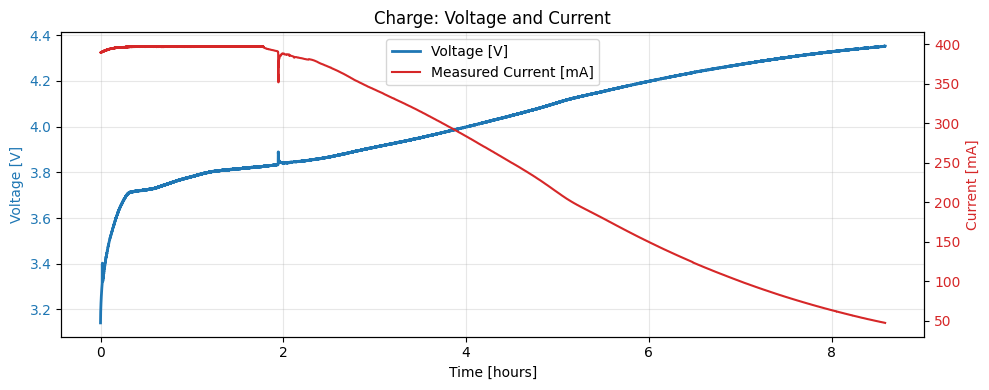

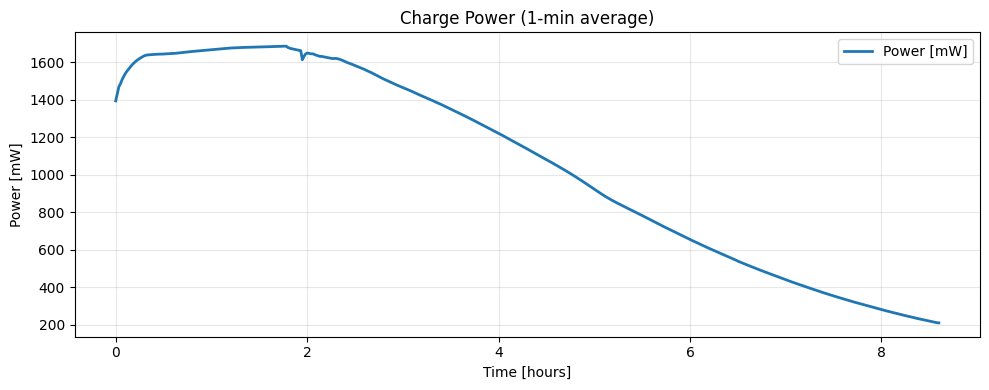

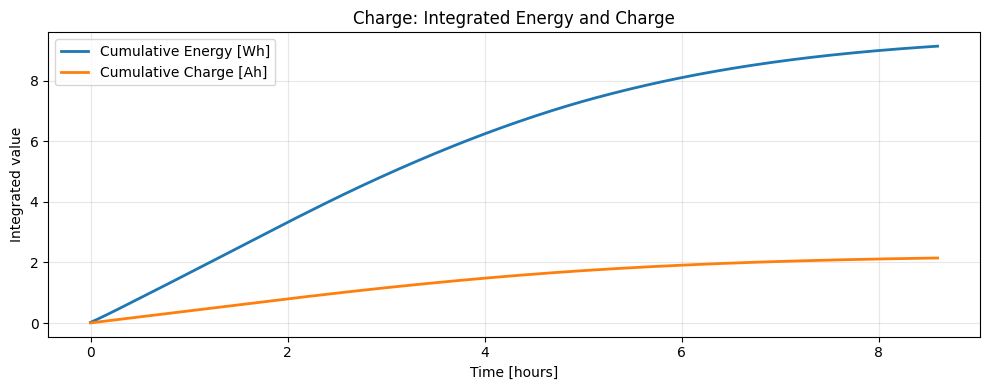

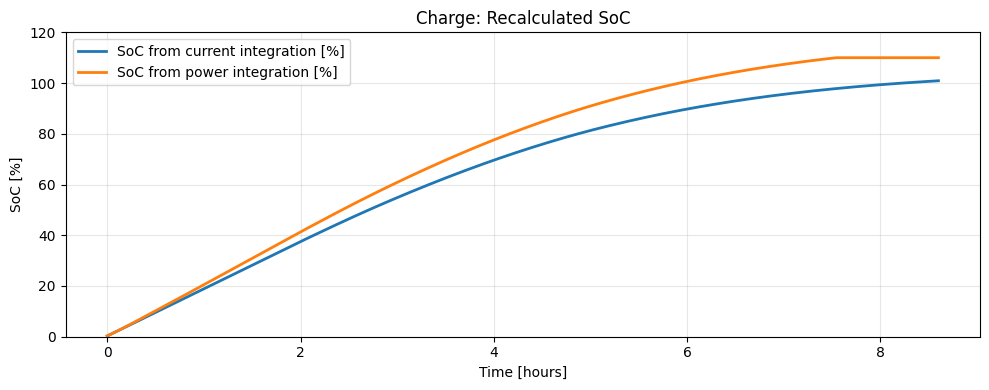

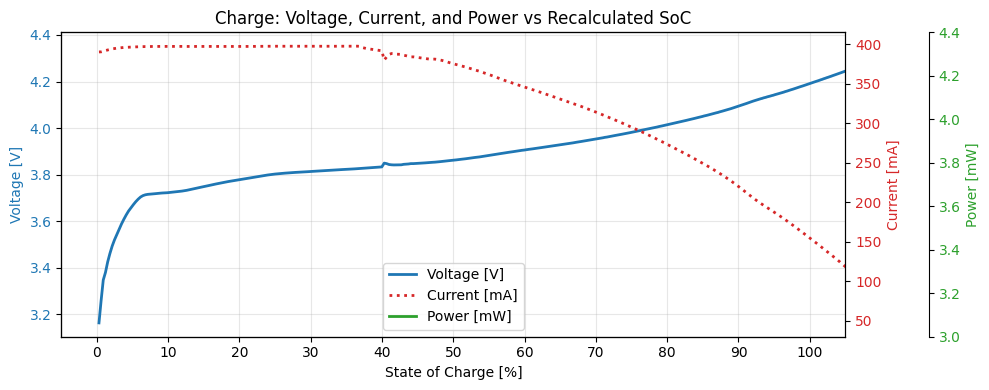

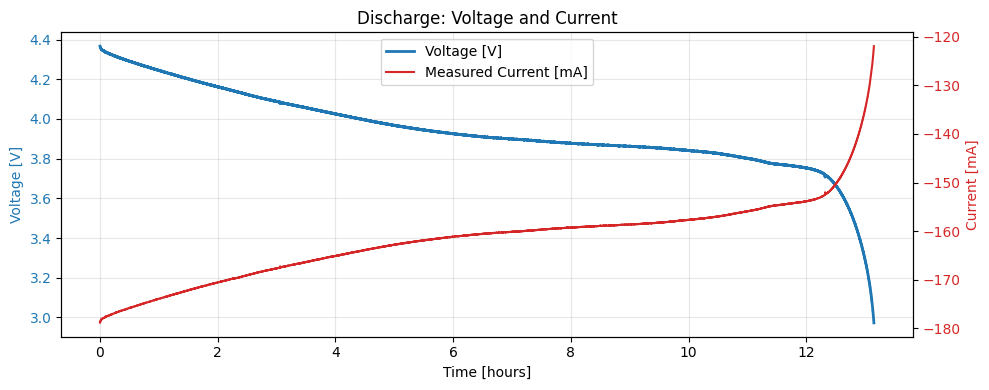

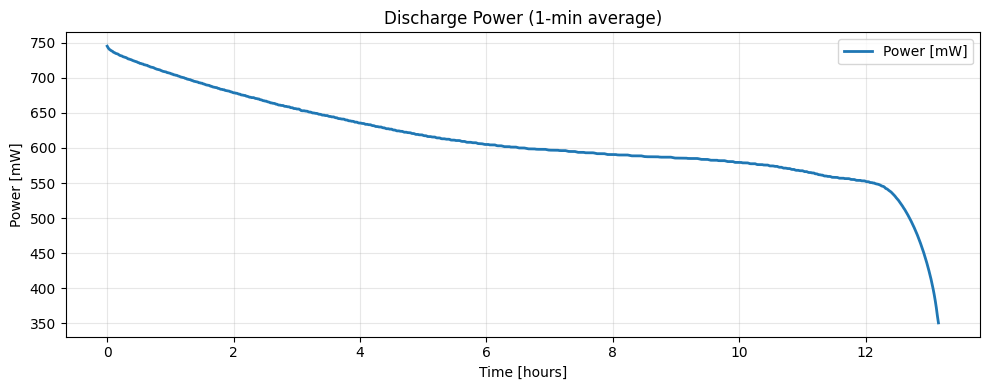

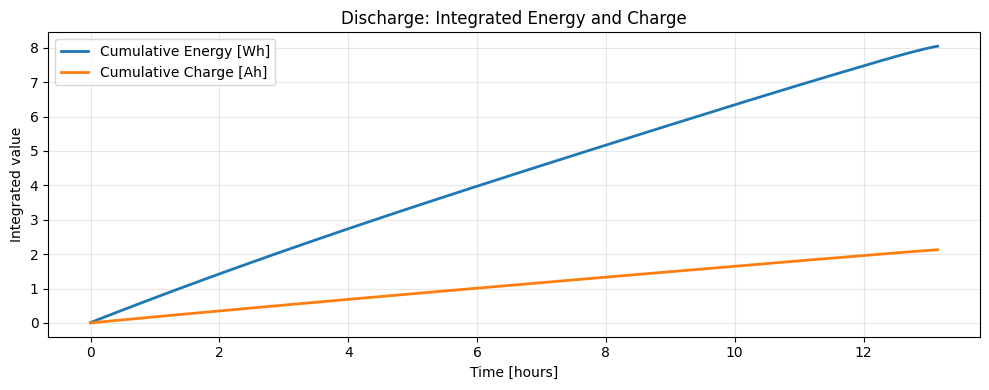

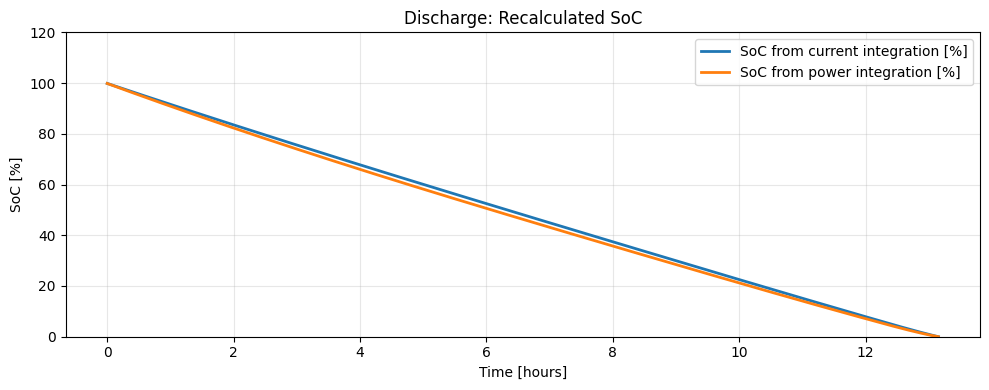

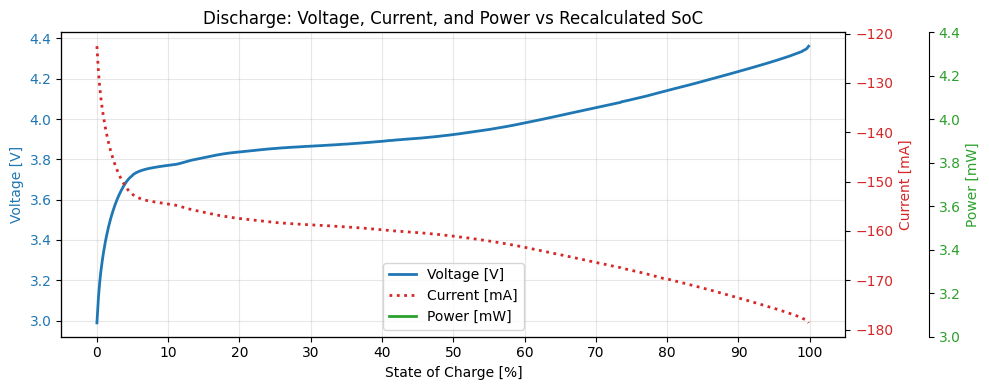

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ----------------------------
# Settings
# ----------------------------
charge_file = Path("BATTERY_CHARGE_ina226_soc_log_20260420_180900.csv")
discharge_file = Path("BATTERY_DISCHARGE_ina226_soc_log_20260421_095715.csv")

resample_interval = "1min"
charge_threshold_mA = 10.0
discharge_threshold_mA = -10.0

# Optional nominal values for comparison only
battery_nominal_Ah = 2.0
battery_nominal_Wh = 7.4


# ----------------------------
# Helpers
# ----------------------------
def load_and_clean(csv_file):
    df = pd.read_csv(csv_file)

    df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
    df = df.dropna(subset=["pc_time"]).copy()
    df = df.sort_values("pc_time").reset_index(drop=True)
    df = df.drop_duplicates(subset="pc_time", keep="first").copy()

    numeric_cols = [
        "elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV",
        "voltage_corrected_V", "soc_voltage_percent", "soc_percent"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "mode" in df.columns:
        df["mode"] = df["mode"].astype(str).str.strip().str.upper()

    df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()
    return df


def extract_active_block(df, target_mode):
    if "mode" in df.columns and (df["mode"] == target_mode).any():
        is_active = df["mode"] == target_mode
    else:
        if target_mode == "CHARGE":
            is_active = df["current_mA"] > charge_threshold_mA
        elif target_mode == "DISCHARGE":
            is_active = df["current_mA"] < discharge_threshold_mA
        else:
            raise ValueError(f"Unsupported target_mode: {target_mode}")

    if not is_active.any():
        raise ValueError(f"No rows found for mode {target_mode}")

    start_idx = is_active.idxmax()
    df_after_start = df.loc[start_idx:].copy()

    if "mode" in df.columns and (df_after_start["mode"] == target_mode).any():
        is_active_after = df_after_start["mode"] == target_mode
    else:
        if target_mode == "CHARGE":
            is_active_after = df_after_start["current_mA"] > charge_threshold_mA
        else:
            is_active_after = df_after_start["current_mA"] < discharge_threshold_mA

    stop_candidates = df_after_start.index[~is_active_after]

    if len(stop_candidates) > 0:
        stop_idx = stop_candidates[0]
        df_block = df.loc[start_idx:stop_idx - 1].copy()
    else:
        df_block = df.loc[start_idx:].copy()

    if df_block.empty:
        raise ValueError(f"Filtered dataframe is empty for mode {target_mode}")

    return df_block


def prepare_block(df_block, mode_name, resample_interval="1min"):
    df_plot = df_block.copy()

    # Relative time
    df_plot["t_hours"] = (
        df_plot["pc_time"] - df_plot["pc_time"].iloc[0]
    ).dt.total_seconds() / 3600.0

    # dt
    dt_s = df_plot["pc_time"].diff().dt.total_seconds()
    dt_s.iloc[0] = 0
    dt_s = dt_s.clip(lower=0, upper=10)
    df_plot["dt_s"] = dt_s
    df_plot["dt_h"] = df_plot["dt_s"] / 3600.0

    # Active current / power as positive quantities
    if mode_name == "CHARGE":
        df_plot["active_current_mA"] = df_plot["current_mA"].clip(lower=0)
        df_plot["active_power_mW"] = df_plot["power_mW"].clip(lower=0)
    elif mode_name == "DISCHARGE":
        df_plot["active_current_mA"] = (-df_plot["current_mA"]).clip(lower=0)
        df_plot["active_power_mW"] = df_plot["power_mW"].abs()
    else:
        raise ValueError("mode_name must be CHARGE or DISCHARGE")

    df_plot["active_current_A"] = df_plot["active_current_mA"] / 1000.0
    df_plot["active_power_W"] = df_plot["active_power_mW"] / 1000.0

    # Incremental Ah / Wh
    df_plot["dQ_Ah"] = df_plot["active_current_A"] * df_plot["dt_h"]
    df_plot["dE_Wh"] = df_plot["active_power_W"] * df_plot["dt_h"]

    df_plot["cum_Ah"] = df_plot["dQ_Ah"].cumsum()
    df_plot["cum_Wh"] = df_plot["dE_Wh"].cumsum()

    # Resample
    df_min = df_plot.set_index("pc_time").resample(resample_interval).mean(numeric_only=True)
    df_min = df_min.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()
    df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

    dt_resample_h = pd.to_timedelta(resample_interval).total_seconds() / 3600.0

    if mode_name == "CHARGE":
        df_min["active_current_mA"] = df_min["current_mA"].clip(lower=0)
        df_min["active_power_mW"] = df_min["power_mW"].clip(lower=0)
    else:
        df_min["active_current_mA"] = (-df_min["current_mA"]).clip(lower=0)
        df_min["active_power_mW"] = df_min["power_mW"].abs()

    df_min["active_current_A"] = df_min["active_current_mA"] / 1000.0
    df_min["active_power_W"] = df_min["active_power_mW"] / 1000.0

    df_min["dQ_Ah"] = df_min["active_current_A"] * dt_resample_h
    df_min["dE_Wh"] = df_min["active_power_W"] * dt_resample_h

    df_min["cum_Ah"] = df_min["dQ_Ah"].cumsum()
    df_min["cum_Wh"] = df_min["dE_Wh"].cumsum()

    return df_plot, df_min


def add_soc_columns(df_min, mode_name, reference_Ah, reference_Wh):
    df_min = df_min.copy()

    # Coulomb-counted SoC
    if mode_name == "CHARGE":
        df_min["soc_from_Ah"] = 100 * df_min["cum_Ah"] / reference_Ah
        df_min["soc_from_Wh"] = 100 * df_min["cum_Wh"] / reference_Wh
    else:
        df_min["soc_from_Ah"] = 100 * (1 - df_min["cum_Ah"] / reference_Ah)
        df_min["soc_from_Wh"] = 100 * (1 - df_min["cum_Wh"] / reference_Wh)

    df_min["soc_from_Ah"] = df_min["soc_from_Ah"].clip(0, 110)
    df_min["soc_from_Wh"] = df_min["soc_from_Wh"].clip(0, 110)

    return df_min


def plot_time_series(df_plot, mode_name):
    fig, ax1 = plt.subplots(figsize=(10, 4))

    y_voltage = "voltage_corrected_V" if "voltage_corrected_V" in df_plot.columns else "bus_V"

    ax1.plot(
        df_plot["t_hours"],
        df_plot[y_voltage],
        color="tab:blue",
        linewidth=2,
        label="Voltage [V]"
    )
    ax1.set_xlabel("Time [hours]")
    ax1.set_ylabel("Voltage [V]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        df_plot["t_hours"],
        df_plot["current_mA"],
        color="tab:red",
        linewidth=1.5,
        label="Measured Current [mA]"
    )
    ax2.set_ylabel("Current [mA]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax1.set_title(f"{mode_name.title()}: Voltage and Current")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")
    plt.tight_layout()


def plot_power_energy(df_min, mode_name):
    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["active_power_mW"], linewidth=2, label="Power [mW]")
    plt.xlabel("Time [hours]")
    plt.ylabel("Power [mW]")
    plt.title(f"{mode_name.title()} Power (1-min average)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["cum_Wh"], linewidth=2, label="Cumulative Energy [Wh]")
    plt.plot(df_min["t_hours"], df_min["cum_Ah"], linewidth=2, label="Cumulative Charge [Ah]")
    plt.xlabel("Time [hours]")
    plt.ylabel("Integrated value")
    plt.title(f"{mode_name.title()}: Integrated Energy and Charge")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


def plot_soc(df_min, mode_name):
    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["soc_from_Ah"], linewidth=2, label="SoC from current integration [%]")
    plt.plot(df_min["t_hours"], df_min["soc_from_Wh"], linewidth=2, label="SoC from power integration [%]")
    plt.xlabel("Time [hours]")
    plt.ylabel("SoC [%]")
    plt.title(f"{mode_name.title()}: Recalculated SoC")
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 120)
    plt.legend()
    plt.tight_layout()


def plot_vs_soc(df_min, mode_name):
    soc_plot = df_min.dropna(subset=["soc_from_Wh", "bus_V", "current_mA", "active_power_mW"]).copy()
    soc_plot = soc_plot.sort_values("soc_from_Wh")

    y_voltage = "voltage_corrected_V" if "voltage_corrected_V" in soc_plot.columns else "bus_V"

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(
        soc_plot["soc_from_Wh"],
        soc_plot[y_voltage],
        color="tab:blue",
        linewidth=2,
        label="Voltage [V]"
    )
    ax1.set_xlabel("State of Charge [%]")
    ax1.set_ylabel("Voltage [V]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        soc_plot["soc_from_Wh"],
        soc_plot["current_mA"],
        color="tab:red",
        linestyle=":",
        linewidth=2,
        label="Current [mA]"
    )
    ax2.set_ylabel("Current [mA]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))
    ax3.plot(
        soc_plot["soc_from_Wh"],
        soc_plot["active_power_mW"],
        color="tab:green",
        linewidth=2,
        label="Power [mW]"
    )
    ax3.set_ylabel("Power [mW]", color="tab:green")
    ax3.tick_params(axis="y", labelcolor="tab:green")

    ax1.set_xlim(-5, 105)
    ax1.set_xticks(np.arange(0, 101, 10))
    ax1.set_title(f"{mode_name.title()}: Voltage, Current, and Power vs Recalculated SoC")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc="lower center")

    plt.tight_layout()


# ----------------------------
# Load and prepare both datasets
# ----------------------------
df_charge_raw = load_and_clean(charge_file)
df_discharge_raw = load_and_clean(discharge_file)

df_charge_block = extract_active_block(df_charge_raw, "CHARGE")
df_discharge_block = extract_active_block(df_discharge_raw, "DISCHARGE")

df_charge_plot, df_charge_min = prepare_block(df_charge_block, "CHARGE", resample_interval)
df_discharge_plot, df_discharge_min = prepare_block(df_discharge_block, "DISCHARGE", resample_interval)

# ----------------------------
# Define measured reference capacity from full discharge test
# ----------------------------
measured_capacity_Ah = df_discharge_min["cum_Ah"].iloc[-1]
measured_capacity_Wh = df_discharge_min["cum_Wh"].iloc[-1]

# Add recalculated SoC
df_charge_min = add_soc_columns(df_charge_min, "CHARGE", measured_capacity_Ah, measured_capacity_Wh)
df_discharge_min = add_soc_columns(df_discharge_min, "DISCHARGE", measured_capacity_Ah, measured_capacity_Wh)

# ----------------------------
# Print summary
# ----------------------------
print("\nMeasured reference capacity from discharge test")
print("--------------------------------------------------")
print(f"Measured usable capacity: {measured_capacity_Ah:.4f} Ah")
print(f"Measured usable energy:   {measured_capacity_Wh:.4f} Wh")
print(f"Nominal capacity:         {battery_nominal_Ah:.4f} Ah")
print(f"Nominal energy:           {battery_nominal_Wh:.4f} Wh")

print("\nCharge dataset")
print("--------------------------------------------------")
print(f"Charge duration:          {df_charge_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Integrated charge:        {df_charge_min['cum_Ah'].iloc[-1]:.4f} Ah")
print(f"Integrated charge energy: {df_charge_min['cum_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from Ah:        {df_charge_min['soc_from_Ah'].iloc[-1]:.2f} %")
print(f"Final SoC from Wh:        {df_charge_min['soc_from_Wh'].iloc[-1]:.2f} %")

print("\nDischarge dataset")
print("--------------------------------------------------")
print(f"Discharge duration:          {df_discharge_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Integrated discharged Ah:    {df_discharge_min['cum_Ah'].iloc[-1]:.4f} Ah")
print(f"Integrated discharged Wh:    {df_discharge_min['cum_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from Ah:           {df_discharge_min['soc_from_Ah'].iloc[-1]:.2f} %")
print(f"Final SoC from Wh:           {df_discharge_min['soc_from_Wh'].iloc[-1]:.2f} %")

# ----------------------------
# Plots
# ----------------------------
plot_time_series(df_charge_plot, "CHARGE")
plot_power_energy(df_charge_min, "CHARGE")
plot_soc(df_charge_min, "CHARGE")
plot_vs_soc(df_charge_min, "CHARGE")

plot_time_series(df_discharge_plot, "DISCHARGE")
plot_power_energy(df_discharge_min, "DISCHARGE")
plot_soc(df_discharge_min, "DISCHARGE")
plot_vs_soc(df_discharge_min, "DISCHARGE")

plt.show()

## SoC Mapping

### V1 - Discharge

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# User settings
# ============================================================
csv_file = Path("BATTERY_ina226_log_20260419_093223.csv")

# Output files
lookup_csv_file = Path("soc_voltage_lookup_1percent.csv")
full_processed_csv = Path("battery_discharge_processed_with_soc.csv")
arduino_header_file = Path("soc_voltage_lookup_arduino.h")

# Battery settings from datasheet / project assumptions
battery_capacity_Ah = 2.0          # 2000 mAh
battery_capacity_Wh = 7.4          # 3.7 V * 2.0 Ah
full_voltage_V = 4.2               # limited charge voltage
rated_cutoff_voltage_V = 2.75      # datasheet rated capacity test cutoff
protection_cutoff_voltage_V = 2.5  # protection threshold, not recommended normal endpoint

# Discharge detection
discharge_threshold_mA = -10.0     # discharge if current_mA < this threshold
idle_threshold_mA = 5.0            # near-zero current threshold

# Smoothing / averaging
resample_rule = "1min"             # smoother lookup table basis
rolling_window = 5                 # optional smoothing after resampling

# Choose SoC basis:
# "energy" -> SoC based on Wh removed
# "charge" -> SoC based on Ah removed
soc_basis = "energy"

# If True, anchor 100% and 0% to the observed discharge window only.
# If False, use nominal 2.0 Ah / 7.4 Wh from datasheet.
normalize_to_measured_test = True

# ============================================================
# Load and clean
# ============================================================
df = pd.read_csv(csv_file)

required_cols = ["pc_time", "elapsed_s", "bus_V", "current_mA", "power_mW"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
df = df.dropna(subset=["pc_time"]).copy()
df = df.sort_values("pc_time").reset_index(drop=True)
df = df.drop_duplicates(subset="pc_time", keep="first").copy()

numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()

if df.empty:
    raise ValueError("No valid rows after cleaning.")

# ============================================================
# Detect first continuous discharge block
# ============================================================
is_discharge = df["current_mA"] < discharge_threshold_mA

if not is_discharge.any():
    raise ValueError(
        f"No discharge rows found with current_mA < {discharge_threshold_mA}. "
        f"Try a threshold closer to zero, e.g. -1.0."
    )

start_idx = is_discharge.idxmax()
df_after_start = df.loc[start_idx:].copy()
is_discharge_after = df_after_start["current_mA"] < discharge_threshold_mA

stop_candidates = df_after_start.index[~is_discharge_after]
if len(stop_candidates) > 0:
    stop_idx = stop_candidates[0]
    df_dis = df.loc[start_idx:stop_idx - 1].copy()
else:
    df_dis = df.loc[start_idx:].copy()

if df_dis.empty:
    raise ValueError("Discharge block is empty.")

# ============================================================
# Time step
# ============================================================
df_dis["dt_s"] = df_dis["pc_time"].diff().dt.total_seconds()
df_dis["dt_s"] = df_dis["dt_s"].clip(lower=0, upper=10)
df_dis.loc[df_dis.index[0], "dt_s"] = 0.0

# ============================================================
# Derived quantities
# ============================================================
# Discharge current magnitude in A / mA
df_dis["discharge_current_mA"] = df_dis["current_mA"].abs()
df_dis["discharge_current_A"] = df_dis["discharge_current_mA"] / 1000.0

# Use absolute power as discharged power magnitude
df_dis["discharge_power_mW"] = df_dis["power_mW"].abs()
df_dis["discharge_power_W"] = df_dis["discharge_power_mW"] / 1000.0

# Integrated charge and energy removed
df_dis["dQ_Ah"] = df_dis["discharge_current_A"] * df_dis["dt_s"] / 3600.0
df_dis["dE_Wh"] = df_dis["discharge_power_W"] * df_dis["dt_s"] / 3600.0

df_dis["cum_Q_Ah"] = df_dis["dQ_Ah"].cumsum()
df_dis["cum_E_Wh"] = df_dis["dE_Wh"].cumsum()

# Relative time
df_dis["t_hours"] = (df_dis["pc_time"] - df_dis["pc_time"].iloc[0]).dt.total_seconds() / 3600.0

# Estimated load resistance from V / I
df_dis["R_eq_ohm"] = df_dis["bus_V"] / df_dis["discharge_current_A"]
df_dis.loc[~np.isfinite(df_dis["R_eq_ohm"]), "R_eq_ohm"] = np.nan

# ============================================================
# Resample for a smoother lookup basis
# ============================================================
df_min = df_dis.set_index("pc_time").resample(resample_rule).mean(numeric_only=True)
df_min = df_min.dropna(subset=["bus_V", "discharge_current_mA", "discharge_power_mW"]).copy()

if df_min.empty:
    raise ValueError("No data left after resampling.")

# Rebuild dt on the resampled frame
df_min["dt_s"] = df_min.index.to_series().diff().dt.total_seconds().fillna(0.0)

# Re-integrate on resampled data
df_min["dQ_Ah"] = (df_min["discharge_current_mA"] / 1000.0) * df_min["dt_s"] / 3600.0
df_min["dE_Wh"] = (df_min["discharge_power_mW"] / 1000.0) * df_min["dt_s"] / 3600.0
df_min["cum_Q_Ah"] = df_min["dQ_Ah"].cumsum()
df_min["cum_E_Wh"] = df_min["dE_Wh"].cumsum()
df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

# Optional smoothing
for col in ["bus_V", "discharge_current_mA", "discharge_power_mW"]:
    df_min[col] = df_min[col].rolling(rolling_window, center=True, min_periods=1).mean()

# ============================================================
# SoC estimation
# ============================================================
if soc_basis == "energy":
    total_used = df_min["cum_E_Wh"].iloc[-1] if normalize_to_measured_test else battery_capacity_Wh
    if total_used <= 0:
        raise ValueError("Total discharged energy is not positive.")
    df_min["soc_percent"] = 100.0 * (1.0 - df_min["cum_E_Wh"] / total_used)

elif soc_basis == "charge":
    total_used = df_min["cum_Q_Ah"].iloc[-1] if normalize_to_measured_test else battery_capacity_Ah
    if total_used <= 0:
        raise ValueError("Total discharged charge is not positive.")
    df_min["soc_percent"] = 100.0 * (1.0 - df_min["cum_Q_Ah"] / total_used)

else:
    raise ValueError("soc_basis must be 'energy' or 'charge'")

df_min["soc_percent"] = df_min["soc_percent"].clip(lower=0.0, upper=100.0)

# ============================================================
# Build 1% lookup table
# ============================================================
# Sort by SoC descending for interpolation
lookup_src = df_min.dropna(subset=["soc_percent", "bus_V"]).copy()
lookup_src = lookup_src.sort_values("soc_percent", ascending=False)

# Remove duplicate SoC values to make interpolation stable
lookup_src = lookup_src.drop_duplicates(subset="soc_percent", keep="first")

if len(lookup_src) < 2:
    raise ValueError("Not enough unique SoC points to build a lookup table.")

# x = SoC, y = voltage
x_soc = lookup_src["soc_percent"].to_numpy()
y_v = lookup_src["bus_V"].to_numpy()

# Ensure ascending x for np.interp
order = np.argsort(x_soc)
x_soc = x_soc[order]
y_v = y_v[order]

# 0..100% in 1% steps
soc_grid = np.arange(0, 101, 1, dtype=float)
voltage_grid = np.interp(soc_grid, x_soc, y_v)

lookup_df = pd.DataFrame({
    "soc_percent": soc_grid.astype(int),
    "voltage_V": voltage_grid
})

# Also add nominal-based helper columns
lookup_df["estimated_remaining_Wh"] = round(battery_capacity_Wh * lookup_df["soc_percent"] / 100.0,4)
lookup_df["estimated_remaining_mAh"] = round(battery_capacity_Ah * 1000.0 * lookup_df["soc_percent"] / 100.0,4)

# Sort descending so 100% is first
lookup_df = lookup_df.sort_values("soc_percent", ascending=False).reset_index(drop=True)

# ============================================================
# Merge row-wise SoC back to the full discharge data
# ============================================================
# Interpolate row-wise SoC from the resampled cumulative basis
if soc_basis == "energy":
    total_used_row = df_dis["cum_E_Wh"].iloc[-1] if normalize_to_measured_test else battery_capacity_Wh
    df_dis["soc_percent"] = 100.0 * (1.0 - df_dis["cum_E_Wh"] / total_used_row)
else:
    total_used_row = df_dis["cum_Q_Ah"].iloc[-1] if normalize_to_measured_test else battery_capacity_Ah
    df_dis["soc_percent"] = 100.0 * (1.0 - df_dis["cum_Q_Ah"] / total_used_row)

df_dis["soc_percent"] = df_dis["soc_percent"].clip(lower=0.0, upper=100.0)

# ============================================================
# Save files
# ============================================================
lookup_df.to_csv(lookup_csv_file, index=False)
df_dis.to_csv(full_processed_csv, index=False)

# Arduino-friendly header
voltage_array = ", ".join(f"{v:.4f}" for v in lookup_df["voltage_V"].to_list())

header_text = f"""#ifndef SOC_VOLTAGE_LOOKUP_ARDUINO_H
#define SOC_VOLTAGE_LOOKUP_ARDUINO_H

// Generated from discharge data
// Index = SoC percent
// Example: soc_voltage_table[100] = voltage at 100% SoC
//          soc_voltage_table[0]   = voltage at 0% SoC

const int SOC_LOOKUP_SIZE = 101;

const float soc_voltage_table[SOC_LOOKUP_SIZE] = {{
{voltage_array}
}};

#endif
"""

with open(arduino_header_file, "w", encoding="utf-8") as f:
    f.write(header_text)

# ============================================================
# Console summary
# ============================================================
print("Done.")
print()
print(f"Input CSV:                  {csv_file}")
print(f"Processed discharge CSV:    {full_processed_csv}")
print(f"Lookup table CSV:           {lookup_csv_file}")
print(f"Arduino header:             {arduino_header_file}")
print()
print(f"Rows in original file:      {len(df)}")
print(f"Rows in discharge block:    {len(df_dis)}")
print(f"Discharge start:            {df_dis['pc_time'].iloc[0]}")
print(f"Discharge end:              {df_dis['pc_time'].iloc[-1]}")
print(f"Observed voltage start [V]: {df_dis['bus_V'].iloc[0]:.4f}")
print(f"Observed voltage end [V]:   {df_dis['bus_V'].iloc[-1]:.4f}")
print(f"Integrated charge [Ah]:     {df_dis['cum_Q_Ah'].iloc[-1]:.4f}")
print(f"Integrated energy [Wh]:     {df_dis['cum_E_Wh'].iloc[-1]:.4f}")
print(f"Estimated mean load [ohm]:  {df_dis['R_eq_ohm'].dropna().mean():.2f}")
print()
print("First 10 lookup rows:")
print(lookup_df.head(10).to_string(index=False))

Done.

Input CSV:                  BATTERY_ina226_log_20260419_093223.csv
Processed discharge CSV:    battery_discharge_processed_with_soc.csv
Lookup table CSV:           soc_voltage_lookup_1percent.csv
Arduino header:             soc_voltage_lookup_arduino.h

Rows in original file:      44371
Rows in discharge block:    39101
Discharge start:            2026-04-19 10:40:02.801000
Discharge end:              2026-04-19 21:33:02.974000
Observed voltage start [V]: 3.9713
Observed voltage end [V]:   2.8163
Integrated charge [Ah]:     1.7178
Integrated energy [Wh]:     6.3263
Estimated mean load [ohm]:  23.29

First 10 lookup rows:
 soc_percent  voltage_V  estimated_remaining_Wh  estimated_remaining_mAh
         100   3.957636                   7.400                   2000.0
          99   3.942880                   7.326                   1980.0
          98   3.931716                   7.252                   1960.0
          97   3.922258                   7.178                   1940.0

### V2 - Charge

C:\Users\Jacob\AppData\Local\Temp\ipykernel_23876\1428821338.py:83: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0


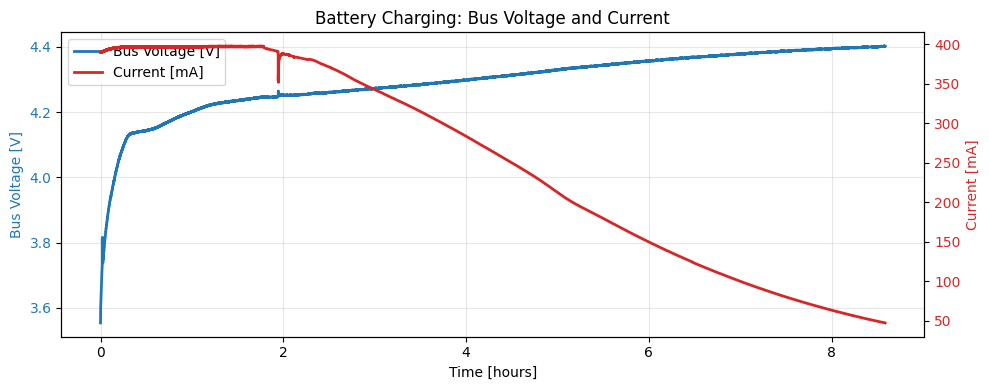

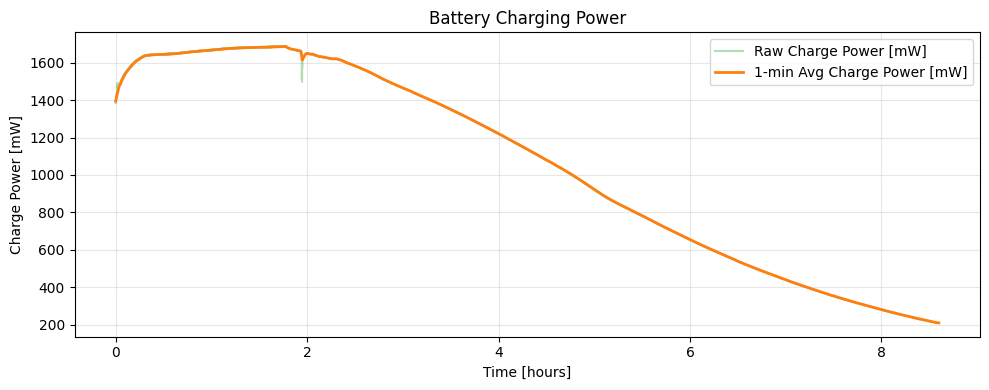

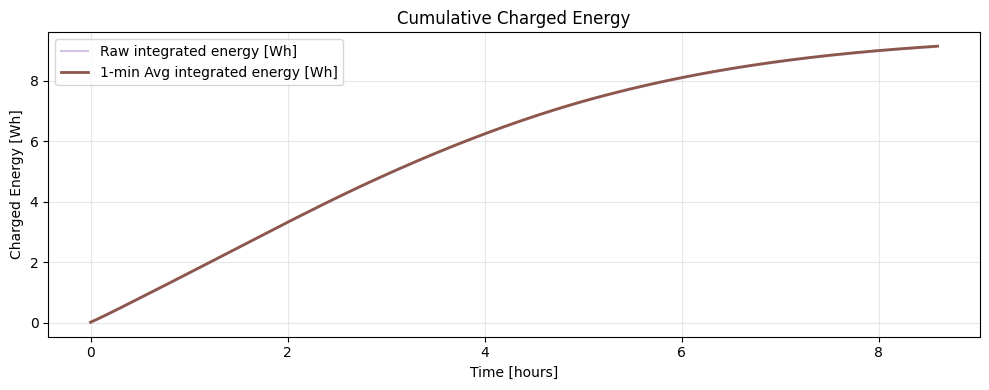

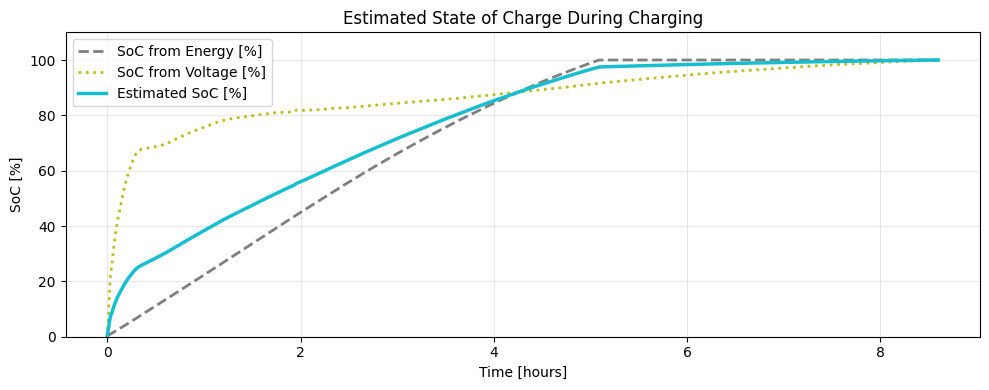

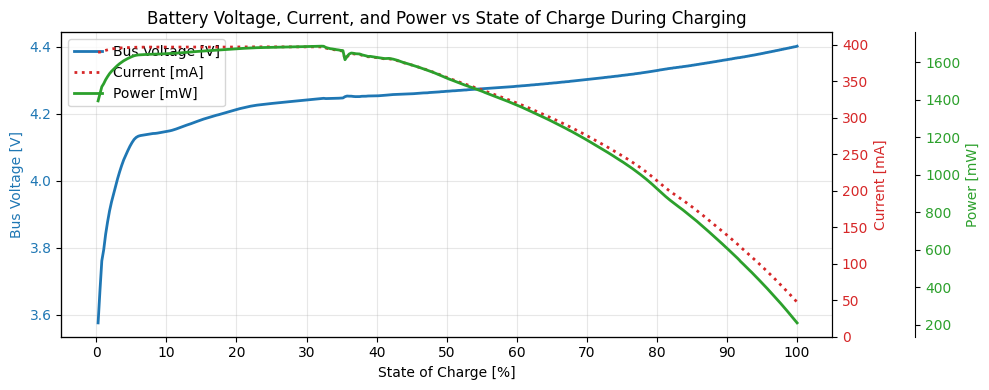

Original rows: 56108
Charge rows used: 30846
Charge start: 2026-04-20 18:09:55.085000
Charge end:   2026-04-21 02:45:02.356000
Duration:     8.585 h
Final integrated charged energy: 9.1133 Wh
Final 1-min averaged integrated energy: 9.1382 Wh
Final SoC from energy: 100.00 %
Final SoC from voltage: 100.00 %
Final estimated SoC: 100.00 %


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ----------------------------
# Settings
# ----------------------------
csv_file = Path("BATTERY_CHARGE_ina226_soc_log_20260420_180900.csv")

# Positive current = charge
charge_threshold_mA = 10.0

# Battery nominal energy
battery_capacity_Wh = 7.4

# Weighting for combined SoC estimate
# 0.7 = energy-based, 0.3 = voltage-based
soc_energy_weight = 0.7
soc_voltage_weight = 0.3

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(csv_file)

df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
df = df.dropna(subset=["pc_time"]).copy()
df = df.sort_values("pc_time").reset_index(drop=True)
df = df.drop_duplicates(subset="pc_time", keep="first").copy()

numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()

# Clean mode column if present
if "mode" in df.columns:
    df["mode"] = df["mode"].astype(str).str.strip().str.upper()

# ----------------------------
# Find charge block
# ----------------------------
if "mode" in df.columns and (df["mode"] == "CHARGE").any():
    is_charge = df["mode"] == "CHARGE"
else:
    is_charge = df["current_mA"] > charge_threshold_mA

if not is_charge.any():
    raise ValueError(
        f"No rows found for charge detection. "
        f"Try mode='CHARGE' or current_mA > {charge_threshold_mA}"
    )

start_idx = is_charge.idxmax()
df_after_start = df.loc[start_idx:].copy()

if "mode" in df.columns and (df_after_start["mode"] == "CHARGE").any():
    is_charge_after = df_after_start["mode"] == "CHARGE"
else:
    is_charge_after = df_after_start["current_mA"] > charge_threshold_mA

stop_candidates = df_after_start.index[~is_charge_after]

if len(stop_candidates) > 0:
    stop_idx = stop_candidates[0]
    df_plot = df.loc[start_idx:stop_idx - 1].copy()
else:
    df_plot = df.loc[start_idx:].copy()

if df_plot.empty:
    raise ValueError("Filtered dataframe is empty after charge block detection.")

# ----------------------------
# Time handling
# ----------------------------
df_plot["t_hours"] = (
    df_plot["pc_time"] - df_plot["pc_time"].iloc[0]
).dt.total_seconds() / 3600.0

dt_s = df_plot["pc_time"].diff().dt.total_seconds()
dt_s.iloc[0] = 0
dt_s = dt_s.clip(lower=0, upper=10)
df_plot["dt_s"] = dt_s

# ----------------------------
# Power / energy as positive charge values
# ----------------------------
df_plot["charge_power_W"] = df_plot["power_mW"].clip(lower=0) / 1000.0
df_plot["dE_Wh"] = df_plot["charge_power_W"] * df_plot["dt_s"] / 3600.0
df_plot["cum_energy_Wh"] = df_plot["dE_Wh"].cumsum()

# ----------------------------
# Minute averaging
# ----------------------------
df_min = df_plot.set_index("pc_time").resample("1min").mean(numeric_only=True)
df_min = df_min.dropna(subset=["power_mW", "bus_V"]).copy()

df_min["charge_power_W"] = df_min["power_mW"].clip(lower=0) / 1000.0
df_min["dE_Wh"] = df_min["charge_power_W"] * (1 / 60.0)
df_min["cum_energy_Wh"] = df_min["dE_Wh"].cumsum()
df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

# ----------------------------
# SoC estimate
# ----------------------------

# 1) Energy-based SoC:
# start near 0%, increase with charged energy
df_min["soc_energy_percent"] = 100 * (df_min["cum_energy_Wh"] / battery_capacity_Wh)
df_min["soc_energy_percent"] = df_min["soc_energy_percent"].clip(lower=0, upper=100)

# 2) Voltage-based SoC:
# start voltage -> 0%, end voltage -> 100%
V_min = df_min["bus_V"].iloc[0]
V_max = df_min["bus_V"].max()

if abs(V_max - V_min) < 1e-9:
    df_min["soc_voltage_percent"] = 0.0
else:
    df_min["soc_voltage_percent"] = 100 * (df_min["bus_V"] - V_min) / (V_max - V_min)
    df_min["soc_voltage_percent"] = df_min["soc_voltage_percent"].clip(lower=0, upper=100)

# 3) Combined SoC estimate
df_min["soc_estimated_percent"] = (
    soc_energy_weight * df_min["soc_energy_percent"] +
    soc_voltage_weight * df_min["soc_voltage_percent"]
).clip(lower=0, upper=100)

# ----------------------------
# Plot 1: Voltage + Current
# ----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    df_plot["t_hours"],
    df_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("Time [hours]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["t_hours"],
    df_plot["current_mA"],
    color="tab:red",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Battery Charging: Bus Voltage and Current")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()

# ----------------------------
# Plot 2: Charge power
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["power_mW"].clip(lower=0),
    color="tab:green",
    alpha=0.35,
    label="Raw Charge Power [mW]"
)
plt.plot(
    df_min["t_hours"],
    df_min["power_mW"].clip(lower=0),
    color="tab:orange",
    linewidth=2,
    label="1-min Avg Charge Power [mW]"
)
plt.xlabel("Time [hours]")
plt.ylabel("Charge Power [mW]")
plt.title("Battery Charging Power")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 3: Cumulative charged energy
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["cum_energy_Wh"],
    color="tab:purple",
    alpha=0.4,
    label="Raw integrated energy [Wh]"
)
plt.plot(
    df_min["t_hours"],
    df_min["cum_energy_Wh"],
    color="tab:brown",
    linewidth=2,
    label="1-min Avg integrated energy [Wh]"
)
plt.xlabel("Time [hours]")
plt.ylabel("Charged Energy [Wh]")
plt.title("Cumulative Charged Energy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 4: SoC estimate
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_min["t_hours"],
    df_min["soc_energy_percent"],
    color="tab:gray",
    linestyle="--",
    linewidth=2,
    label="SoC from Energy [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_voltage_percent"],
    color="tab:olive",
    linestyle=":",
    linewidth=2,
    label="SoC from Voltage [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_estimated_percent"],
    color="tab:cyan",
    linewidth=2.5,
    label="Estimated SoC [%]"
)
plt.xlabel("Time [hours]")
plt.ylabel("SoC [%]")
plt.title("Estimated State of Charge During Charging")
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.show()

# ----------------------------
# Plot 5: Voltage, Current, Power vs SoC
# ----------------------------
soc_plot = df_min.dropna(subset=["bus_V", "current_mA", "power_mW", "cum_energy_Wh"]).copy()

if soc_plot["cum_energy_Wh"].iloc[-1] > 0:
    soc_plot["soc_plot_percent"] = 100 * (
        soc_plot["cum_energy_Wh"] / soc_plot["cum_energy_Wh"].iloc[-1]
    )
else:
    soc_plot["soc_plot_percent"] = 0.0

soc_plot["soc_plot_percent"] = soc_plot["soc_plot_percent"].clip(0, 110)
soc_plot = soc_plot.sort_values("soc_plot_percent", ascending=True)

fig, ax1 = plt.subplots(figsize=(10, 4))

# Voltage on left axis
ax1.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("State of Charge [%]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Current on first right axis
ax2 = ax1.twinx()
ax2.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["current_mA"],
    color="tab:red",
    linestyle=":",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0, max(soc_plot["current_mA"].max() * 1.05, 1))

# Power on second right axis
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["power_mW"].clip(lower=0),
    color="tab:green",
    linewidth=2,
    label="Power [mW]"
)
ax3.set_ylabel("Power [mW]", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")

# Force SoC axis from 0 to 100 with 10% intervals
ax1.set_xlim(-5, 105)
ax1.set_xticks(np.arange(0, 101, 10))

ax1.set_title("Battery Voltage, Current, and Power vs State of Charge During Charging")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="best"
)

plt.tight_layout()
plt.show()

# ----------------------------
# Summary
# ----------------------------
print(f"Original rows: {len(df)}")
print(f"Charge rows used: {len(df_plot)}")
print(f"Charge start: {df_plot['pc_time'].iloc[0]}")
print(f"Charge end:   {df_plot['pc_time'].iloc[-1]}")
print(f"Duration:     {df_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Final integrated charged energy: {df_plot['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final 1-min averaged integrated energy: {df_min['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from energy: {df_min['soc_energy_percent'].iloc[-1]:.2f} %")
print(f"Final SoC from voltage: {df_min['soc_voltage_percent'].iloc[-1]:.2f} %")
print(f"Final estimated SoC: {df_min['soc_estimated_percent'].iloc[-1]:.2f} %")

## Internal resistance Mapping


=== SEGMENT SUMMARY ===
 segment_id  start_s    end_s  duration_s  mean_bus_V  mean_current_mA  mean_power_mW  estimated_load_ohm  n_points  matched_resistor_count  matched_load_ohm  load_match_error_ohm
          1   0.0000 180.7490    180.7490      3.7131         -39.8119       147.1186             93.2649       177                       2          110.0000               16.7351
          2 180.7490 211.8050     31.0560      3.5900        -154.0259       553.1250             23.3079        27                       9           24.4444                1.1366
          3 211.8050 239.8610     28.0560      3.7500          -0.0260         0.0000         144231.0769        25                       1          220.0000           144011.0769

=== STEP-TO-STEP R_eff ESTIMATES ===
 from_segment  to_segment    V1_V    V2_V     I1_A     I2_A  deltaV_V  deltaI_A  R_eff_ohm
            1           2 3.71305 3.59002 -0.03981 -0.15403  -0.12303  -0.11421    1.07721
            2           3 3.59002 3

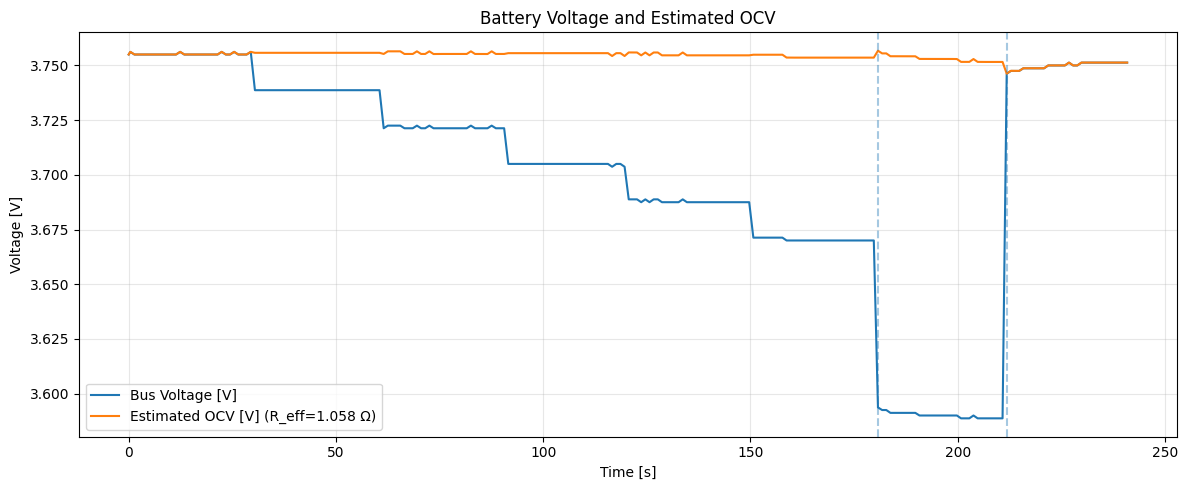

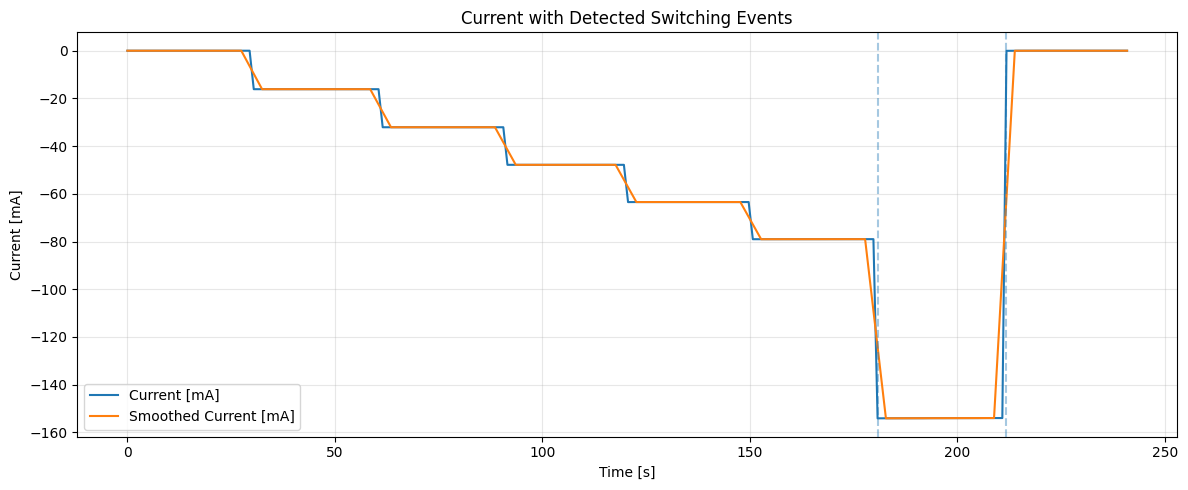

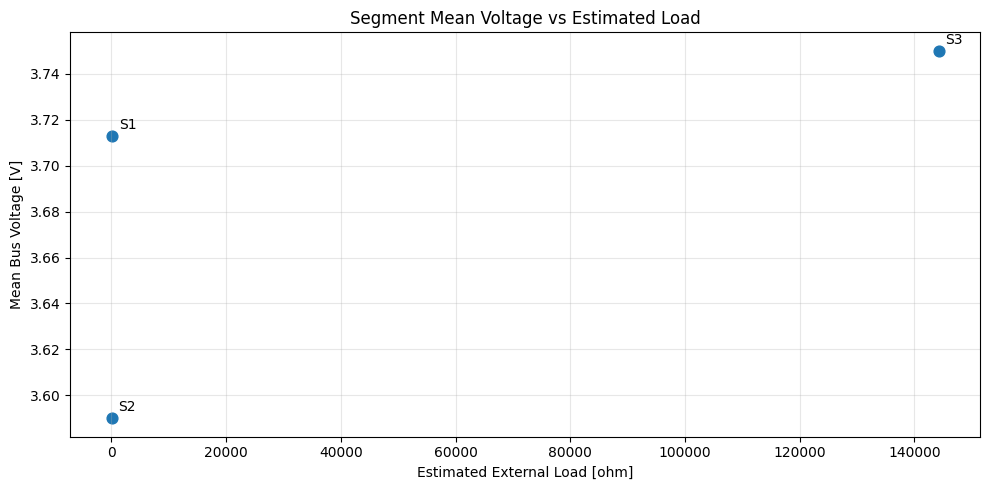

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Settings
# ============================================================
csv_file = Path("battery_varied_load_sequence.csv")

# Smoothing / segmentation settings
rolling_window = 5                 # samples for smoothing
change_threshold_mA = 8.0          # current step threshold for detecting a switch
min_segment_duration_s = 8.0       # ignore very short segments
edge_ignore_s = 2.0                # ignore data near each switching edge when averaging

# Optional known resistor-bank mapping
# number of 220 ohm resistors in parallel -> equivalent resistance
known_loads = {
    0: np.inf,
    1: 220.0,
    2: 110.0,
    3: 220.0 / 3.0,
    4: 55.0,
    5: 44.0,
    6: 220.0 / 6.0,
    7: 220.0 / 7.0,
    8: 27.5,
    9: 220.0 / 9.0,
    10: 22.0,
}

# ============================================================
# Load and clean
# ============================================================
df = pd.read_csv(csv_file)

df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
df = df.dropna(subset=["pc_time"]).copy()
df = df.sort_values("pc_time").reset_index(drop=True)
df = df.drop_duplicates(subset="pc_time", keep="first").copy()

for col in ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["elapsed_s", "bus_V", "current_mA"]).copy()

# Relative time
df["t_s"] = df["elapsed_s"] - df["elapsed_s"].iloc[0]

# ============================================================
# Smooth current and voltage
# ============================================================
df["current_smooth_mA"] = df["current_mA"].rolling(
    rolling_window, center=True, min_periods=1
).mean()

df["voltage_smooth_V"] = df["bus_V"].rolling(
    rolling_window, center=True, min_periods=1
).mean()

# ============================================================
# Detect switching events from current changes
# ============================================================
df["dI_mA"] = df["current_smooth_mA"].diff().abs().fillna(0.0)

# Candidate switch points
switch_mask = df["dI_mA"] > change_threshold_mA
switch_indices = df.index[switch_mask].tolist()

# Merge nearby detections into single switching events
merged_switches = []
if switch_indices:
    current_group = [switch_indices[0]]

    for idx in switch_indices[1:]:
        if idx - current_group[-1] <= rolling_window:
            current_group.append(idx)
        else:
            merged_switches.append(int(np.median(current_group)))
            current_group = [idx]

    merged_switches.append(int(np.median(current_group)))

# Segment boundaries
boundaries = [0] + merged_switches + [len(df) - 1]

# ============================================================
# Build stable segments
# ============================================================
segments = []

for seg_id in range(len(boundaries) - 1):
    start_idx = boundaries[seg_id]
    end_idx = boundaries[seg_id + 1]

    seg = df.loc[start_idx:end_idx].copy()

    if seg.empty:
        continue

    t_start = seg["t_s"].iloc[0]
    t_end = seg["t_s"].iloc[-1]
    duration = t_end - t_start

    if duration < min_segment_duration_s:
        continue

    # Ignore edges to avoid switching transients
    seg_core = seg[
        (seg["t_s"] >= t_start + edge_ignore_s) &
        (seg["t_s"] <= t_end - edge_ignore_s)
    ].copy()

    if len(seg_core) < 3:
        seg_core = seg.copy()

    mean_V = seg_core["bus_V"].mean()
    mean_I_mA = seg_core["current_mA"].mean()
    mean_I_A = mean_I_mA / 1000.0
    mean_P_mW = seg_core["power_mW"].mean()

    if abs(mean_I_A) > 1e-6:
        est_load_ohm = mean_V / abs(mean_I_A)
    else:
        est_load_ohm = np.inf

    segments.append({
        "segment_id": seg_id + 1,
        "start_s": t_start,
        "end_s": t_end,
        "duration_s": duration,
        "mean_bus_V": mean_V,
        "mean_current_mA": mean_I_mA,
        "mean_power_mW": mean_P_mW,
        "estimated_load_ohm": est_load_ohm,
        "n_points": len(seg_core),
    })

segments_df = pd.DataFrame(segments)

# ============================================================
# Try matching each segment to the nearest known resistor-bank load
# ============================================================
if not segments_df.empty:
    def nearest_load(r):
        if not np.isfinite(r):
            return (0, np.inf)
        best_n = None
        best_r = None
        best_err = np.inf
        for n, r_known in known_loads.items():
            if not np.isfinite(r_known):
                continue
            err = abs(r - r_known)
            if err < best_err:
                best_err = err
                best_n = n
                best_r = r_known
        return best_n, best_r

    match = segments_df["estimated_load_ohm"].apply(nearest_load)
    segments_df["matched_resistor_count"] = [m[0] for m in match]
    segments_df["matched_load_ohm"] = [m[1] for m in match]
    segments_df["load_match_error_ohm"] = (
        segments_df["estimated_load_ohm"] - segments_df["matched_load_ohm"]
    ).abs()

# ============================================================
# Estimate effective series resistance from adjacent segment steps
# Model: V_term = V_oc - I * R_eff
# => deltaV = -R_eff * deltaI
# => R_eff = -deltaV / deltaI
# Use signed current in A
# ============================================================
step_results = []

for i in range(len(segments_df) - 1):
    s1 = segments_df.iloc[i]
    s2 = segments_df.iloc[i + 1]

    V1 = s1["mean_bus_V"]
    V2 = s2["mean_bus_V"]
    I1 = s1["mean_current_mA"] / 1000.0
    I2 = s2["mean_current_mA"] / 1000.0

    dV = V2 - V1
    dI = I2 - I1

    if abs(dI) > 1e-6:
        R_eff = dV / dI
    else:
        R_eff = np.nan

    step_results.append({
        "from_segment": int(s1["segment_id"]),
        "to_segment": int(s2["segment_id"]),
        "V1_V": V1,
        "V2_V": V2,
        "I1_A": I1,
        "I2_A": I2,
        "deltaV_V": dV,
        "deltaI_A": dI,
        "R_eff_ohm": R_eff,
    })

steps_df = pd.DataFrame(step_results)

# Keep only physically plausible values
valid_reff = steps_df["R_eff_ohm"].replace([np.inf, -np.inf], np.nan).dropna()
valid_reff = valid_reff[(valid_reff > 0) & (valid_reff < 5.0)]  # loose filter

R_eff_mean = valid_reff.mean() if len(valid_reff) else np.nan
R_eff_median = valid_reff.median() if len(valid_reff) else np.nan

# ============================================================
# Correct voltage to estimated OCV using median R_eff
# V_oc_est = V_term - I * R_eff
# with signed current
# ============================================================
if np.isfinite(R_eff_median):
    df["ocv_est_V"] = df["bus_V"] - (df["current_mA"] / 1000.0) * R_eff_median
else:
    df["ocv_est_V"] = np.nan

# ============================================================
# Print summary
# ============================================================
print("\n=== SEGMENT SUMMARY ===")
if not segments_df.empty:
    print(segments_df.to_string(index=False, float_format=lambda x: f"{x:0.4f}"))
else:
    print("No stable segments found. Try lowering change_threshold_mA or min_segment_duration_s.")

print("\n=== STEP-TO-STEP R_eff ESTIMATES ===")
if not steps_df.empty:
    print(steps_df.to_string(index=False, float_format=lambda x: f"{x:0.5f}"))
else:
    print("No adjacent segment transitions found.")

print("\n=== EFFECTIVE SERIES RESISTANCE SUMMARY ===")
print(f"Mean R_eff   = {R_eff_mean:.5f} ohm")
print(f"Median R_eff = {R_eff_median:.5f} ohm")

# ============================================================
# Plots
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(df["t_s"], df["bus_V"], label="Bus Voltage [V]")
if np.isfinite(R_eff_median):
    plt.plot(df["t_s"], df["ocv_est_V"], label=f"Estimated OCV [V] (R_eff={R_eff_median:.3f} Ω)")
for idx in merged_switches:
    plt.axvline(df.loc[idx, "t_s"], linestyle="--", alpha=0.4)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Battery Voltage and Estimated OCV")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.plot(df["t_s"], df["current_mA"], label="Current [mA]")
plt.plot(df["t_s"], df["current_smooth_mA"], label="Smoothed Current [mA]")
for idx in merged_switches:
    plt.axvline(df.loc[idx, "t_s"], linestyle="--", alpha=0.4)
plt.xlabel("Time [s]")
plt.ylabel("Current [mA]")
plt.title("Current with Detected Switching Events")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

if not segments_df.empty:
    plt.figure(figsize=(10, 5))
    plt.scatter(
        segments_df["estimated_load_ohm"],
        segments_df["mean_bus_V"],
        s=60
    )
    for _, row in segments_df.iterrows():
        plt.annotate(
            f"S{int(row['segment_id'])}",
            (row["estimated_load_ohm"], row["mean_bus_V"]),
            xytext=(5, 5),
            textcoords="offset points"
        )
    plt.xlabel("Estimated External Load [ohm]")
    plt.ylabel("Mean Bus Voltage [V]")
    plt.title("Segment Mean Voltage vs Estimated Load")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

plt.show()